# IMPORTING DATA - pandas_datareader

### STOCK DATA

In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import yfinance as yf

In [4]:
import datetime
stock_symbol='LMND'
start=datetime.datetime(2016,1,1)
end=datetime.datetime(2021,6,16)
data_source='yahoo'

In [5]:
df = yf.download(stock_symbol, start, end)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['LMND']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


In [6]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,LMND,LMND,LMND,LMND,LMND,LMND
Date,,,,,,


In [9]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,LMND,LMND,LMND,LMND,LMND,LMND
Date,,,,,,


In [12]:
import pandas_datareader.data as web
import datetime



def get_historical_data(stock_symbol='AAPL',
                        start=datetime.datetime(2016,1,1),
                        end=datetime.datetime(2018,1,1)):
    """Returns a DF with OHLC Historical Data for a given Stock. 
    Google Finance as main data provider, alternatively: yahoo"""

    try:
        data_source='google'
        df = yf.download(stock_symbol, start, end)
        
    except:
        data_source='yahoo'
        df = web.DataReader(stock_symbol,data_source, start, end)
        df['Close'] = df['Adj Close']    
    
    return df, data_source



In [13]:
start = datetime.datetime(2020, 1, 1)
end = datetime.datetime(2021, 6, 16)
stock_symbol = 'BTC-USD'

df_stock, data_source = get_historical_data(stock_symbol,start,end)

print("Data Source :{}".format(data_source))
print("Stock Symbol: {}".format(stock_symbol))

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BTC-USD']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Data Source :google
Stock Symbol: BTC-USD


In [16]:
df_stock.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,


In [18]:
df_stock.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,


In [20]:
DAYRANGE = df_stock['High']/df_stock['Low']-1
print("The biggest price variation in one day has been {:.2f}%".format(100*max(DAYRANGE)))

ValueError: Unknown format code 'f' for object of type 'str'

In [ ]:
INTRADAY = df_stock['Close']/df_stock['Open']-1
print("The largest price variation between closing and opening has been {:.2f}%".format(100*max(INTRADAY)))
print("The largest negative price variation between closing and opening has been {:.2f}%".format(100*min(INTRADAY)))

In [ ]:
df_stock.tail()

In [ ]:
df_stock['CloseYesterday'] = df_stock['Close'].shift(1)

In [ ]:
df_stock[['Open','Close','CloseYesterday']].tail()

In [ ]:
OVERNIGHT = df_stock['Open'] / df_stock['Close'].shift(1) - 1
OVERNIGHT.dropna(inplace=True)
print("The largest overnight variation has been {:.2f}%".format(100*max(OVERNIGHT)))
print("The largest overnight negative variation has been {:.2f}%".format(100*min(OVERNIGHT)))
#OVERNIGHT.head()

In [27]:
print("Stock Symbol: {}".format(stock_symbol))

INTRADAY = df_stock['Close'][:] / df_stock['Open'][:]
max_intra = max(INTRADAY)
print("max_intra:", max_intra)


OVERNIGHT = df_stock['Open'][1:] / df_stock['Close'].shift(1)
max_over =  max(OVERNIGHT[1:])
print("max_over:", max_over)


Stock Symbol: BTC-USD
max_intra: BTC-USD
max_over: BTC-USD


In [29]:
import matplotlib.pyplot as plt
%matplotlib inline
df_stock['Close'].plot(figsize=(12,8))

<Axes: xlabel='Date'>

In [30]:
df_stock['Close'].tail()

Ticker,BTC-USD
Date,


In [32]:
df_stock['Close'].iloc[-1]

IndexError: single positional indexer is out-of-bounds

In [ ]:
df_stock['Close'][-1]

In [35]:
df_stock['Close'][len(df_stock)-1]

KeyError: -1

In [ ]:
df_stock['Close'][0]

In [ ]:
df_stock['Close'].plot(figsize=(12,8))
plt.title("Closing Prices - {}".format(stock_symbol))
plt.show()

accumulated_return_perc = 100*(df_stock['Close'][-1]/df_stock['Close'].iloc[0]-1)
print("-"*50)
print("Accumulated Return over the period: {0:.4g} %".format(accumulated_return_perc))

### MARKET DATA

In [ ]:
#market data (SPY)
df_index, data_source = get_historical_data('^GSPC',start,end)
print(data_source)

In [ ]:
df_index.head()

In [40]:
df_index.tail()

NameError: name 'df_index' is not defined

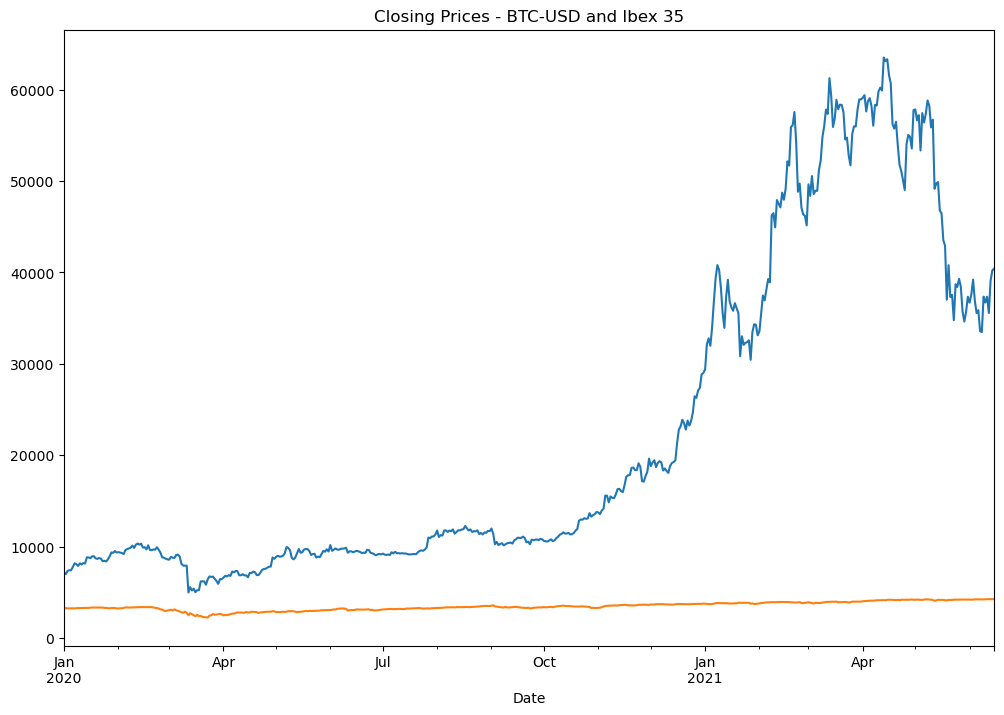

--------------------------------------------------
Accumulated Return over the period: 30.35 %


C:\Users\manoe\AppData\Local\Temp\ipykernel_13148\1012858550.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  accumulated_return_perc = 100*(df_index['Close'][-1]/df_index['Close'].iloc[0]-1)


In [27]:
df_stock['Close'].plot(figsize=(12,8))
df_index['Close'].plot(figsize=(12,8))
plt.title("Closing Prices - {} and {}".format(stock_symbol,'Ibex 35'))
plt.show()

accumulated_return_perc = 100*(df_index['Close'][-1]/df_index['Close'].iloc[0]-1)
print("-"*50)
print("Accumulated Return over the period: {0:.4g} %".format(accumulated_return_perc))

C:\Users\manoe\AppData\Local\Temp\ipykernel_13148\2355080687.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (df_stock['Close']/df_stock['Close'][0]).plot(figsize=(12,8))
C:\Users\manoe\AppData\Local\Temp\ipykernel_13148\2355080687.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (df_index['Close']/df_index['Close'][0]).plot(figsize=(12,8))


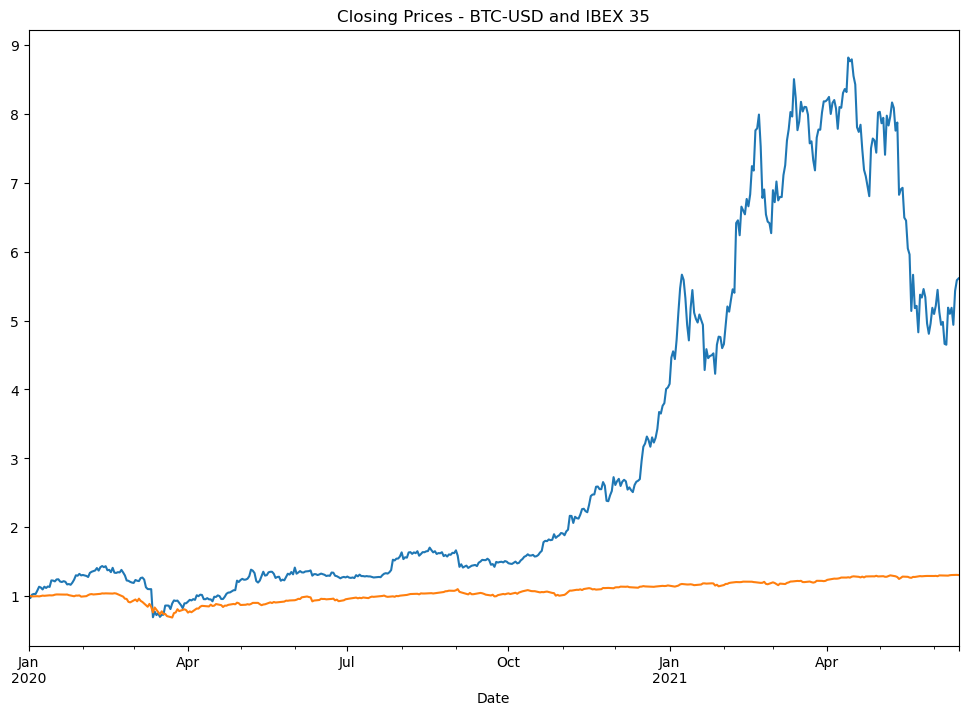

In [28]:
#To solve scale problems
(df_stock['Close']/df_stock['Close'][0]).plot(figsize=(12,8))
(df_index['Close']/df_index['Close'][0]).plot(figsize=(12,8))
plt.title("Closing Prices - {} and {}".format(stock_symbol,'IBEX 35'))
plt.show()

# Exercicio - Incluir las demás acciones de Ibex 35 - 
por lo menos 
* TEF.MC, 
* SAN.MC
* MRL.MC

In [29]:
import datetime
stock_symbols=['TEF.MC',"SAN.MC", "MRL.MC", "^IBEX",'REP.MC']
start=datetime.datetime(2020,1,1)
end=datetime.datetime(2020,7,6)
data_source='yahoo'


In [30]:
import pandas_datareader.data as web
df = yf.download(stock_symbols, start, end)

[*********************100%%**********************]  5 of 5 completed


In [31]:
df.head()

Adj Close                                              Close  \
              MRL.MC     REP.MC    SAN.MC    TEF.MC        ^IBEX MRL.MC   
Date                                                                      
2020-01-02  9.819274  10.939440  3.269158  4.537585  9691.200195  12.81   
2020-01-03  9.826939  11.075549  3.218421  4.541169  9646.599609  12.82   
2020-01-06  9.796277  11.161106  3.191784  4.546901  9600.900391  12.78   
2020-01-07  9.742620  11.067773  3.176563  4.478106  9579.799805  12.71   
2020-01-08  9.635306  11.168882  3.178676  4.415044  9591.400391  12.57   

                                                  ...   Open          \
            REP.MC    SAN.MC TEF.MC        ^IBEX  ... MRL.MC  REP.MC   
Date                                              ...                  
2020-01-02  14.065  3.704917  6.332  9691.200195  ...  12.89  14.030   
2020-01-03  14.240  3.647417  6.337  9646.599609  ...  12.75  14.105   
2020-01-06  14.350  3.617230  6.345  9600.900391  ...  12.71  14.260   
2020-01-07  14.230  3.599980  6.249  9579.799805  ...  12.82  14.365   
2020-01-08  14.360  3.602375  6.161  9591.400391  ...  12.66  14.230   

                                           Volume                     \
              SAN.MC TEF.MC        ^IBEX   MRL.MC   REP.MC    SAN.MC   
Date                                                                   
2020-01-02  3.612917  6.280  9639.099609   460980  5576733  49940748   
2020-01-03  3.676167  6.319  9631.200195  1432326  4769535  39751027   
2020-01-06  3.612917  6.307  9585.400391   532601  3960659  26771979   
2020-01-07  3.638313  6.345  9623.099609   653971  6809406  30226212   
2020-01-08  3.576500  6.237  9535.099609   966373  4661762  31351924   

                                 
              TEF.MC      ^IBEX  
Date                             
2020-01-02  18745661  142379600  
2020-01-03  23660471  135130000  
2020-01-06   7527476  103520400  
2020-01-07  12480889  133476100  
2020-01-08  20622100  133957600  

[5 rows x 30 columns]

In [32]:
import matplotlib.pyplot as plt
%matplotlib inline

In [33]:
df_close = df['Close']

In [34]:
df_close.head()

,MRL.MC,REP.MC,SAN.MC,TEF.MC,^IBEX
Date,,,,,
2020-01-02,12.81,14.065,3.704917,6.332,9691.200195
2020-01-03,12.82,14.240,3.647417,6.337,9646.599609
2020-01-06,12.78,14.350,3.617230,6.345,9600.900391
2020-01-07,12.71,14.230,3.599980,6.249,9579.799805
2020-01-08,12.57,14.360,3.602375,6.161,9591.400391


C:\Users\manoe\AppData\Local\Temp\ipykernel_13148\2745571597.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (df['Close']["TEF.MC"]/df['Close']["TEF.MC"][0]).plot(figsize=(12,8))
C:\Users\manoe\AppData\Local\Temp\ipykernel_13148\2745571597.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (df['Close']["SAN.MC"]/df['Close']["SAN.MC"][0]).plot(figsize=(12,8))
C:\Users\manoe\AppData\Local\Temp\ipykernel_13148\2745571597.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access 

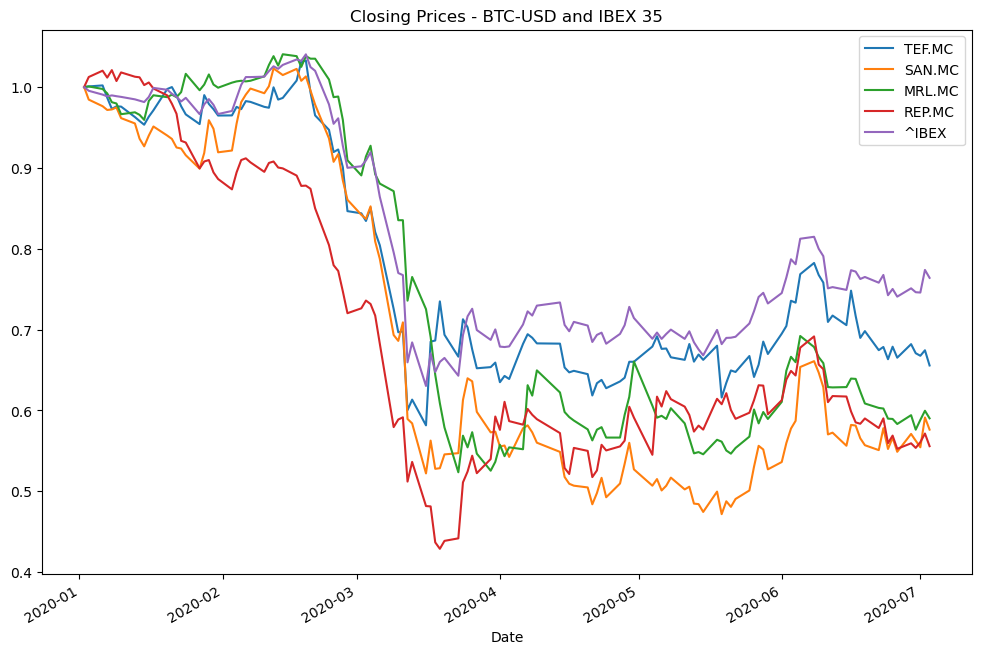

In [35]:
(df['Close']["TEF.MC"]/df['Close']["TEF.MC"][0]).plot(figsize=(12,8))
(df['Close']["SAN.MC"]/df['Close']["SAN.MC"][0]).plot(figsize=(12,8))
(df['Close']["MRL.MC"]/df['Close']["MRL.MC"][0]).plot(figsize=(12,8))
(df['Close']["REP.MC"]/df['Close']["REP.MC"][0]).plot(figsize=(12,8))
(df['Close']["^IBEX"]/df['Close']["^IBEX"][0]).plot(figsize=(12,8))
plt.title("Closing Prices - {} and {}".format(stock_symbol,'IBEX 35'))
plt.legend()
plt.show()

In [36]:
for company in df['Close'].columns:
#    print("Empresa - {}".format(company))
    accumulated_return_perc = 100*(df['Close'][company][-1]/df['Close'][company].iloc[0]-1)
    print("-"*50)
    print("{} accumulated Return over the period: {} %".format(company,accumulated_return_perc))

--------------------------------------------------
MRL.MC accumulated Return over the period: -40.98360893726066 %
--------------------------------------------------
REP.MC accumulated Return over the period: -44.42943321774199 %
--------------------------------------------------
SAN.MC accumulated Return over the period: -42.38230095238291 %
--------------------------------------------------
TEF.MC accumulated Return over the period: -34.44409084124711 %
--------------------------------------------------
^IBEX accumulated Return over the period: -23.60595333093035 %


C:\Users\manoe\AppData\Local\Temp\ipykernel_13148\349410469.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  accumulated_return_perc = 100*(df['Close'][company][-1]/df['Close'][company].iloc[0]-1)
